In [ ]:
# Cell 1 - Setup and Organise All RProp Work

from google.colab import drive
drive.mount("/content/gdrive", force_remount=False)

from pathlib import Path
import os, sys, shutil, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/content/gdrive/MyDrive/PointNet_APS_Project_V2")
SRC_DIR = PROJECT_DIR / "src"

RPROP_ROOT = PROJECT_DIR / "RPROP_OPTIMIZER_COMPARISON"

V1_DIR = RPROP_ROOT / "version_1_initial"
V2_DIR = RPROP_ROOT / "version_2_clean"
V3_DIR = RPROP_ROOT / "version_3_final_hybrid"

V3_MODEL_DIR = V3_DIR / "models"
V3_RESULTS_DIR = V3_DIR / "results"
V3_YCB_DIR = V3_RESULTS_DIR / "ycb28_results"
V3_TABLE_DIR = V3_DIR / "tables"
V3_HISTORY_DIR = V3_DIR / "histories"
V3_FIG_DIR = V3_DIR / "figures"

FINAL_COMPARE_DIR = RPROP_ROOT / "final_comparison_tables"

CACHE_DIR = Path("/content/pointnetpp_rprop_v3_cache")

for d in [
    RPROP_ROOT,
    V1_DIR,
    V2_DIR,
    V3_DIR,
    V3_MODEL_DIR,
    V3_RESULTS_DIR,
    V3_YCB_DIR,
    V3_TABLE_DIR,
    V3_HISTORY_DIR,
    V3_FIG_DIR,
    FINAL_COMPARE_DIR,
    CACHE_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("RProp root folder:", RPROP_ROOT)
print("Final v3 folder:", V3_DIR)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Project folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2
RProp root folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON
Final v3 folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid


In [ ]:
# Cell 2 - Move Existing RProp v1 and v2 Folders

def move_folder_if_exists(src, dst_parent):
    src = Path(src)
    dst_parent = Path(dst_parent)

    if not src.exists():
        print("Not found, skipping:", src)
        return

    dst = dst_parent / src.name

    if dst.exists():
        print("Already organised, skipping:", dst)
        return

    dst_parent.mkdir(parents=True, exist_ok=True)

    print("Moving:")
    print("FROM:", src)
    print("TO:  ", dst)

    shutil.move(str(src), str(dst))

# Version 1 folders
move_folder_if_exists(PROJECT_DIR / "models_rprop_xyz", V1_DIR)
move_folder_if_exists(PROJECT_DIR / "results_rprop_xyz", V1_DIR)
move_folder_if_exists(PROJECT_DIR / "figures_rprop_xyz", V1_DIR)

# Version 2 folders
move_folder_if_exists(PROJECT_DIR / "models_rprop_xyz_v2", V2_DIR)
move_folder_if_exists(PROJECT_DIR / "results_rprop_xyz_v2", V2_DIR)
move_folder_if_exists(PROJECT_DIR / "figures_rprop_xyz_v2", V2_DIR)

print("\nRProp folder organisation complete.")

for p in sorted(RPROP_ROOT.iterdir()):
    print("-", p)

Not found, skipping: /content/gdrive/MyDrive/PointNet_APS_Project_V2/models_rprop_xyz
Not found, skipping: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_rprop_xyz
Not found, skipping: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_rprop_xyz
Not found, skipping: /content/gdrive/MyDrive/PointNet_APS_Project_V2/models_rprop_xyz_v2
Not found, skipping: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_rprop_xyz_v2
Not found, skipping: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_rprop_xyz_v2

RProp folder organisation complete.
- /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/final_comparison_tables
- /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_1_initial
- /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_2_clean
- /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid


In [ ]:
# Cell 3 - Imports and Final RProp v3 Settings

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import mannwhitneyu
from tqdm import tqdm

utility_path = SRC_DIR / "pointnetpp_aps_utils.py"

if not utility_path.exists():
    raise FileNotFoundError(f"Missing utility file: {utility_path}")

sys.path.insert(0, str(SRC_DIR))

from pointnetpp_aps_utils import PointNetPPClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Final hybrid RProp v3 settings
N_POINTS = 1000
BATCH_SIZE = 16
MAX_EPOCHS = 80
PATIENCE = 20
N_RUNS = 10

RPROP_LR = 0.003
RPROP_ETAS = (0.5, 1.2)
RPROP_STEP_SIZES = (1e-6, 50)

USE_MILD_AUGMENTATION = True
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHTED_LOSS = True
LABEL_SMOOTHING = 0.0

PRIMITIVE_TO_IDX = {
    "box": 0,
    "cylinder": 1,
    "sphere": 2
}

IDX_TO_PRIMITIVE = {
    0: "box",
    1: "cylinder",
    2: "sphere"
}

print("Final RProp v3 settings ready.")
print("Runs:", N_RUNS)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("RProp LR:", RPROP_LR)
print("Mild augmentation:", USE_MILD_AUGMENTATION)
print("Class-weighted loss:", USE_CLASS_WEIGHTED_LOSS)
print("Weighted sampler:", USE_WEIGHTED_SAMPLER)

Device: cuda
Final RProp v3 settings ready.
Runs: 10
Max epochs: 80
Patience: 20
RProp LR: 0.003
Mild augmentation: True
Class-weighted loss: True
Weighted sampler: False


In [ ]:
# Cell 4 - Utility Functions

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def infer_primitive_from_path(path):
    text = str(path).lower()

    if "sphere" in text:
        return "sphere"
    if "cylinder" in text:
        return "cylinder"
    if "box" in text or "cuboid" in text:
        return "box"

    return None

def load_xyz_from_csv(path):
    arr = np.loadtxt(path, delimiter=",").astype(np.float32)

    if arr.ndim == 1:
        arr = arr.reshape(-1, arr.shape[0])

    xyz = arr[:, :3].astype(np.float32)

    if xyz.shape[0] > N_POINTS:
        idx = np.random.choice(xyz.shape[0], N_POINTS, replace=False)
        xyz = xyz[idx]
    elif xyz.shape[0] < N_POINTS:
        idx = np.random.choice(xyz.shape[0], N_POINTS, replace=True)
        xyz = xyz[idx]

    return xyz.astype(np.float32)

def normalise_xyz_bbox_style(xyz):
    xyz = xyz.astype(np.float32)

    xyz = xyz - xyz.mean(axis=0, keepdims=True)

    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    diagonal = np.linalg.norm(maxs - mins)

    if diagonal > 0:
        xyz = xyz / diagonal

    return xyz.astype(np.float32)

def mild_augment_xyz(xyz):
    xyz = xyz.copy().astype(np.float32)

    # Mild random Z rotation
    theta = np.random.uniform(0, 2 * np.pi)
    rot = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ], dtype=np.float32)
    xyz = xyz @ rot.T

    # Mild scale
    scale = np.random.uniform(0.95, 1.05)
    xyz = xyz * scale

    # Mild shift
    shift = np.random.uniform(-0.01, 0.01, size=(1, 3)).astype(np.float32)
    xyz = xyz + shift

    # Mild jitter
    jitter = np.clip(
        np.random.normal(0, 0.002, size=xyz.shape),
        -0.01,
        0.01
    ).astype(np.float32)

    xyz = xyz + jitter

    return xyz.astype(np.float32)

def copy_manifest_to_cache(df, split_name):
    cache_split_dir = CACHE_DIR / split_name
    cache_split_dir.mkdir(parents=True, exist_ok=True)

    cached_paths = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"Caching {split_name}"):
        src = Path(row["path"])

        if not src.exists():
            raise FileNotFoundError(f"Missing source file: {src}")

        dst = cache_split_dir / f"{split_name}_{i:06d}_{src.name}"

        if not dst.exists():
            shutil.copy2(src, dst)

        cached_paths.append(str(dst))

    df = df.copy()
    df["cached_path"] = cached_paths

    return df

In [ ]:
# Cell 5 - Find APS Clean + Error Files for Mixed Training

RAW_DIR = PROJECT_DIR / "data" / "raw"

if not RAW_DIR.exists():
    raise FileNotFoundError(f"Raw data folder not found: {RAW_DIR}")

all_raw_csvs = sorted(RAW_DIR.rglob("*.csv"))

clean_rows = []
error_rows = []

for p in all_raw_csvs:
    primitive = infer_primitive_from_path(p)

    if primitive is None:
        continue

    text = str(p).lower()

    is_clean = "clean" in text
    is_error = "error" in text and "double" not in text
    is_val_or_test = any(x in text for x in ["val", "validation", "test"])

    if is_clean and not is_val_or_test:
        clean_rows.append({
            "path": str(p),
            "primitive_label": primitive,
            "primitive_idx": PRIMITIVE_TO_IDX[primitive],
            "source_set": "clean"
        })

    if is_error and not is_val_or_test:
        error_rows.append({
            "path": str(p),
            "primitive_label": primitive,
            "primitive_idx": PRIMITIVE_TO_IDX[primitive],
            "source_set": "error"
        })

clean_train_df = pd.DataFrame(clean_rows)
error_train_df = pd.DataFrame(error_rows)

mixed_train_df = pd.concat([clean_train_df, error_train_df], ignore_index=True)

print("Clean train files:", len(clean_train_df))
print("Error train files:", len(error_train_df))
print("Mixed train files:", len(mixed_train_df))

print("\nMixed train class counts:")
display(mixed_train_df["primitive_label"].value_counts())

if len(mixed_train_df) == 0:
    raise RuntimeError("No APS mixed training files found.")

Clean train files: 591
Error train files: 591
Mixed train files: 1182

Mixed train class counts:


,count
primitive_label,
box,440
cylinder,380
sphere,362


In [ ]:
# Cell 6 - Find APS Validation Files

GENERATED_DIR = PROJECT_DIR / "data" / "generated"

val_rows = []

if GENERATED_DIR.exists():
    generated_csvs = sorted(GENERATED_DIR.rglob("*.csv"))

    for p in generated_csvs:
        primitive = infer_primitive_from_path(p)

        if primitive is None:
            continue

        text = str(p).lower()

        if "val" in text and "clean" in text:
            val_rows.append({
                "path": str(p),
                "primitive_label": primitive,
                "primitive_idx": PRIMITIVE_TO_IDX[primitive],
                "source_set": "aps_clean_val"
            })

val_df = pd.DataFrame(val_rows)

if len(val_df) == 0:
    print("No generated validation set found. Creating fallback split from mixed training.")

    val_df = (
        mixed_train_df
        .groupby("primitive_label", group_keys=False)
        .sample(frac=0.15, random_state=42)
        .reset_index(drop=True)
    )

    val_paths = set(val_df["path"].tolist())

    mixed_train_df = mixed_train_df[
        ~mixed_train_df["path"].isin(val_paths)
    ].reset_index(drop=True)

print("Validation files:", len(val_df))

print("\nValidation class counts:")
display(val_df["primitive_label"].value_counts())

print("\nTraining class counts:")
display(mixed_train_df["primitive_label"].value_counts())

Validation files: 600

Validation class counts:


,count
primitive_label,
box,200
cylinder,200
sphere,200



Training class counts:


,count
primitive_label,
box,440
cylinder,380
sphere,362


In [ ]:
# Cell 7 - Cache APS Data Locally

mixed_train_cached_df = copy_manifest_to_cache(mixed_train_df, "aps_mixed_train")
val_cached_df = copy_manifest_to_cache(val_df, "aps_val")

train_manifest_path = V3_TABLE_DIR / "rprop_v3_mixed_train_manifest.csv"
val_manifest_path = V3_TABLE_DIR / "rprop_v3_validation_manifest.csv"

mixed_train_cached_df.to_csv(train_manifest_path, index=False)
val_cached_df.to_csv(val_manifest_path, index=False)

print("Cached mixed train:", len(mixed_train_cached_df))
print("Cached validation:", len(val_cached_df))
print("Saved:", train_manifest_path)
print("Saved:", val_manifest_path)

Caching aps_val: 100%|██████████| 600/600 [00:00<00:00, 1733.42it/s]

Cached mixed train: 1182
Cached validation: 600
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_mixed_train_manifest.csv
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_validation_manifest.csv


In [ ]:
# Cell 8 - Dataset and DataLoaders

class PrimitiveCSVDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        path = row["cached_path"] if "cached_path" in row else row["path"]

        xyz = load_xyz_from_csv(path)
        xyz = normalise_xyz_bbox_style(xyz)

        if self.augment:
            xyz = mild_augment_xyz(xyz)

        points = torch.tensor(xyz.T, dtype=torch.float32)
        label = int(row["primitive_idx"])

        return {
            "points": points,
            "label": torch.tensor(label, dtype=torch.long),
            "primitive_label": row["primitive_label"]
        }

def create_train_loader(train_df):
    dataset = PrimitiveCSVDataset(train_df, augment=USE_MILD_AUGMENTATION)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    return loader

def create_eval_loader(df):
    dataset = PrimitiveCSVDataset(df, augment=False)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return loader

train_loader = create_train_loader(mixed_train_cached_df)
val_loader = create_eval_loader(val_cached_df)

batch = next(iter(train_loader))

print("Batch points:", batch["points"].shape)
print("Batch labels:", batch["label"].shape)

Batch points: torch.Size([16, 3, 1000])
Batch labels: torch.Size([16])


In [ ]:
# Cell 9 - Class Weights and Training Functions

def compute_class_weights(train_df):
    counts = train_df["primitive_idx"].value_counts().sort_index()

    class_counts = np.array([
        counts.get(0, 1),
        counts.get(1, 1),
        counts.get(2, 1)
    ], dtype=np.float32)

    weights = class_counts.sum() / (len(class_counts) * class_counts)

    return torch.tensor(weights, dtype=torch.float32).to(device)

class_weights = compute_class_weights(mixed_train_cached_df)

print("Class weights:", class_weights)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in loader:
        points = batch["points"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(points)

        if isinstance(logits, tuple):
            logits = logits[0]

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples * 100

def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in loader:
            points = batch["points"].to(device)
            labels = batch["label"].to(device)

            logits = model(points)

            if isinstance(logits, tuple):
                logits = logits[0]

            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples * 100

Class weights: tensor([0.8955, 1.0368, 1.0884], device='cuda:0')


In [ ]:
# Cell 10 - Train Final RProp v3 Mixed Runs

all_history_rows = []
run_summary_rows = []

for run_id in range(1, N_RUNS + 1):
    print("\n" + "="*90)
    print(f"Final RProp v3 mixed training run {run_id}/{N_RUNS}")
    print("="*90)

    set_seed(3000 + run_id)

    model = PointNetPPClassifier(num_classes=3, normal_channel=False).to(device)

    if USE_CLASS_WEIGHTED_LOSS:
        criterion = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=LABEL_SMOOTHING
        )
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    optimizer = torch.optim.Rprop(
        model.parameters(),
        lr=RPROP_LR,
        etas=RPROP_ETAS,
        step_sizes=RPROP_STEP_SIZES
    )

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    ckpt_path = V3_MODEL_DIR / f"mixed_trained_xyz_rprop_v3_run_{run_id}_best.pth"

    start_time = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = evaluate_model(
            model,
            val_loader,
            criterion
        )

        improved = False

        if val_acc > best_val_acc:
            improved = True
        elif val_acc == best_val_acc and val_loss < best_val_loss:
            improved = True

        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0

            torch.save({
                "run_id": run_id,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "settings": {
                    "optimizer": "RProp",
                    "version": "v3_final_hybrid",
                    "lr": RPROP_LR,
                    "etas": RPROP_ETAS,
                    "step_sizes": RPROP_STEP_SIZES,
                    "batch_size": BATCH_SIZE,
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "label_smoothing": LABEL_SMOOTHING,
                    "mild_augmentation": USE_MILD_AUGMENTATION,
                    "weighted_sampler": USE_WEIGHTED_SAMPLER,
                    "class_weighted_loss": USE_CLASS_WEIGHTED_LOSS,
                    "input": "XYZ only",
                    "training_condition": "mixed APS clean + error"
                }
            }, ckpt_path)

        else:
            patience_counter += 1

        all_history_rows.append({
            "run_id": run_id,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy_percent": train_acc,
            "val_loss": val_loss,
            "val_accuracy_percent": val_acc,
            "best_val_accuracy_percent": best_val_acc,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "patience_counter": patience_counter
        })

        print(
            f"Run {run_id:02d} | Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.2f}% | "
            f"val loss {val_loss:.4f} acc {val_acc:.2f}% | "
            f"best val {best_val_acc:.2f}%"
        )

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    elapsed_minutes = (time.time() - start_time) / 60

    run_summary_rows.append({
        "run_id": run_id,
        "checkpoint": ckpt_path.name,
        "best_epoch": best_epoch,
        "best_val_accuracy_percent": best_val_acc,
        "best_val_loss": best_val_loss,
        "training_time_minutes": elapsed_minutes,
        "checkpoint_path": str(ckpt_path)
    })

history_df = pd.DataFrame(all_history_rows)
train_summary_df = pd.DataFrame(run_summary_rows)

history_path = V3_HISTORY_DIR / "rprop_v3_mixed_training_histories_runs_1_to_10.csv"
train_summary_path = V3_TABLE_DIR / "rprop_v3_mixed_training_summary_runs_1_to_10.csv"

history_df.to_csv(history_path, index=False)
train_summary_df.to_csv(train_summary_path, index=False)

display(train_summary_df)

print("Saved:")
print(history_path)
print(train_summary_path)


Final RProp v3 mixed training run 1/10
Run 01 | Epoch 001 | train loss 0.6956 acc 69.04% | val loss 0.4549 acc 71.17% | best val 71.17%
Run 01 | Epoch 002 | train loss 1.9258 acc 68.95% | val loss 0.4374 acc 73.83% | best val 73.83%
Run 01 | Epoch 003 | train loss 1.7332 acc 70.98% | val loss 0.5109 acc 72.17% | best val 73.83%
Run 01 | Epoch 004 | train loss 1.0539 acc 71.40% | val loss 0.5099 acc 71.00% | best val 73.83%
Run 01 | Epoch 005 | train loss 2.2139 acc 70.73% | val loss 0.4578 acc 73.50% | best val 73.83%
Run 01 | Epoch 006 | train loss 1.5802 acc 72.93% | val loss 0.5092 acc 71.33% | best val 73.83%
Run 01 | Epoch 007 | train loss 1.4164 acc 70.05% | val loss 0.4390 acc 75.00% | best val 75.00%
Run 01 | Epoch 008 | train loss 1.7451 acc 69.29% | val loss 0.5430 acc 72.00% | best val 75.00%
Run 01 | Epoch 009 | train loss 1.0408 acc 72.00% | val loss 0.7289 acc 70.50% | best val 75.00%
Run 01 | Epoch 010 | train loss 2.1833 acc 69.63% | val loss 0.6047 acc 72.67% | best v

,run_id,checkpoint,best_epoch,best_val_accuracy_percent,best_val_loss,training_time_minutes,checkpoint_path
0,1,mixed_trained_xyz_rprop_v3_run_1_best.pth,53,79.500000,0.413256,12.677695,/content/gdrive/MyDrive/PointNet_APS_Project_V...
1,2,mixed_trained_xyz_rprop_v3_run_2_best.pth,40,81.333333,0.449487,10.882445,/content/gdrive/MyDrive/PointNet_APS_Project_V...
2,3,mixed_trained_xyz_rprop_v3_run_3_best.pth,71,85.000000,0.350385,14.476874,/content/gdrive/MyDrive/PointNet_APS_Project_V...
3,4,mixed_trained_xyz_rprop_v3_run_4_best.pth,73,88.000000,0.278432,13.716689,/content/gdrive/MyDrive/PointNet_APS_Project_V...
4,5,mixed_trained_xyz_rprop_v3_run_5_best.pth,28,82.500000,0.411998,8.120005,/content/gdrive/MyDrive/PointNet_APS_Project_V...
5,6,mixed_trained_xyz_rprop_v3_run_6_best.pth,78,82.666667,0.352844,13.485383,/content/gdrive/MyDrive/PointNet_APS_Project_V...
6,7,mixed_trained_xyz_rprop_v3_run_7_best.pth,33,84.666667,0.374620,8.941254,/content/gdrive/MyDrive/PointNet_APS_Project_V...
7,8,mixed_trained_xyz_rprop_v3_run_8_best.pth,24,80.666667,0.430443,7.306888,/content/gdrive/MyDrive/PointNet_APS_Project_V...
8,9,mixed_trained_xyz_rprop_v3_run_9_best.pth,43,80.666667,0.379553,10.521036,/content/gdrive/MyDrive/PointNet_APS_Project_V...
9,10,mixed_trained_xyz_rprop_v3_run_10_best.pth,11,82.333333,0.433955,5.227070,/content/gdrive/MyDrive/PointNet_APS_Project_V...


Saved:
/content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/histories/rprop_v3_mixed_training_histories_runs_1_to_10.csv
/content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_mixed_training_summary_runs_1_to_10.csv


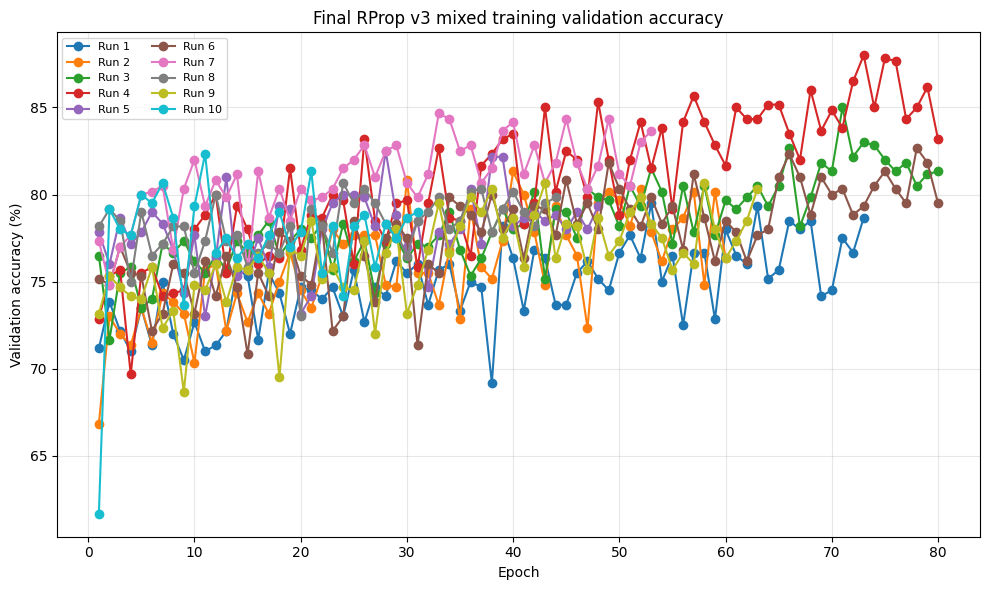

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/figures/rprop_v3_mixed_validation_accuracy_curves.png


In [ ]:
# Cell 11 - Plot RProp v3 Training Curves

plt.figure(figsize=(10, 6))

for run_id in sorted(history_df["run_id"].unique()):
    part = history_df[history_df["run_id"] == run_id]
    plt.plot(part["epoch"], part["val_accuracy_percent"], marker="o", label=f"Run {run_id}")

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy (%)")
plt.title("Final RProp v3 mixed training validation accuracy")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

fig_path = V3_FIG_DIR / "rprop_v3_mixed_validation_accuracy_curves.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [ ]:
# Cell 12 - Load YCB-28 Manifest

ycb_manifest_path = PROJECT_DIR / "metadata" / "ycb28_pointcloud_manifest_bbox_norm.csv"

if not ycb_manifest_path.exists():
    raise FileNotFoundError(f"YCB manifest not found: {ycb_manifest_path}")

ycb_df = pd.read_csv(ycb_manifest_path)

print("YCB manifest loaded:", ycb_manifest_path)
display(ycb_df.head())
print("Rows:", len(ycb_df))
print("Columns:", ycb_df.columns.tolist())

if "primitive_label" not in ycb_df.columns:
    if "class_name" in ycb_df.columns:
        ycb_df = ycb_df.rename(columns={"class_name": "primitive_label"})
    elif "true_primitive" in ycb_df.columns:
        ycb_df = ycb_df.rename(columns={"true_primitive": "primitive_label"})
    elif "label" in ycb_df.columns:
        ycb_df["primitive_label"] = ycb_df["label"].map(IDX_TO_PRIMITIVE)
    else:
        raise RuntimeError("Could not find primitive label column in YCB manifest.")

if "primitive_idx" not in ycb_df.columns:
    if "label" in ycb_df.columns:
        ycb_df["primitive_idx"] = ycb_df["label"].astype(int)
    else:
        ycb_df["primitive_idx"] = ycb_df["primitive_label"].map(PRIMITIVE_TO_IDX)

possible_path_cols = ["pointcloud_path", "csv_path", "path", "file_path"]

path_col = None

for col in possible_path_cols:
    if col in ycb_df.columns:
        path_col = col
        break

if path_col is None:
    raise RuntimeError("Could not find point-cloud path column in YCB manifest.")

ycb_df["path"] = ycb_df[path_col].astype(str)
ycb_df["path"] = ycb_df["path"].str.replace(
    "/content/drive/MyDrive",
    "/content/gdrive/MyDrive",
    regex=False
)

print("\nYCB class counts:")
display(ycb_df["primitive_label"].value_counts())

print("\nYCB object counts:")
display(ycb_df["object_name"].value_counts().head())

YCB manifest loaded: /content/gdrive/MyDrive/PointNet_APS_Project_V2/metadata/ycb28_pointcloud_manifest_bbox_norm.csv


,path,object_name,class_name,label,sample_id,variant,role,source_mesh,source_type,n_points
0,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,0,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
1,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,1,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
2,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,2,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
3,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,3,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
4,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,4,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000


Rows: 560
Columns: ['path', 'object_name', 'class_name', 'label', 'sample_id', 'variant', 'role', 'source_mesh', 'source_type', 'n_points']

YCB class counts:


,count
primitive_label,
sphere,220
box,180
cylinder,160



YCB object counts:


,count
object_name,
003_cracker_box,20
004_sugar_box,20
008_pudding_box,20
009_gelatin_box,20
010_potted_meat_can,20


In [ ]:
# Cell 13 - Cache YCB Files

def copy_ycb_to_cache(df):
    cache_split_dir = CACHE_DIR / "ycb28"
    cache_split_dir.mkdir(parents=True, exist_ok=True)

    cached_paths = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc="Caching YCB"):
        src = Path(row["path"])

        if not src.exists():
            raise FileNotFoundError(f"YCB point-cloud file missing: {src}")

        dst = cache_split_dir / f"ycb_{i:06d}_{src.name}"

        if not dst.exists():
            shutil.copy2(src, dst)

        cached_paths.append(str(dst))

    df = df.copy()
    df["cached_path"] = cached_paths

    return df

ycb_cached_df = copy_ycb_to_cache(ycb_df)

ycb_cached_path = V3_TABLE_DIR / "ycb28_cached_manifest_for_rprop_v3.csv"
ycb_cached_df.to_csv(ycb_cached_path, index=False)

print("Cached YCB files:", len(ycb_cached_df))
print("Saved:", ycb_cached_path)

Caching YCB: 100%|██████████| 560/560 [03:17<00:00,  2.83it/s]

Cached YCB files: 560
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/ycb28_cached_manifest_for_rprop_v3.csv


In [ ]:
# Cell 14 - YCB Dataset and Loader

class YCBPrimitiveDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        xyz = load_xyz_from_csv(row["cached_path"])
        xyz = normalise_xyz_bbox_style(xyz)

        points = torch.tensor(xyz.T, dtype=torch.float32)
        label = int(row["primitive_idx"])

        return {
            "points": points,
            "label": torch.tensor(label, dtype=torch.long),
            "primitive_label": row["primitive_label"],
            "object_name": row["object_name"],
            "sample_id": int(row["sample_id"]) if "sample_id" in self.df.columns else idx,
            "pointcloud_path": row["cached_path"]
        }

ycb_dataset = YCBPrimitiveDataset(ycb_cached_df)

ycb_loader = DataLoader(
    ycb_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

batch = next(iter(ycb_loader))

print("YCB dataset samples:", len(ycb_dataset))
print("Batch points:", batch["points"].shape)
print("Batch labels:", batch["label"].shape)
print("Example objects:", batch["object_name"][:3])

YCB dataset samples: 560
Batch points: torch.Size([16, 3, 1000])
Batch labels: torch.Size([16])
Example objects: ['003_cracker_box', '003_cracker_box', '003_cracker_box']


In [ ]:
# Cell 15 - Evaluate Final RProp v3 Checkpoints on YCB-28

def load_checkpoint(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    else:
        state = ckpt

    clean_state = {k.replace("module.", ""): v for k, v in state.items()}

    model.load_state_dict(clean_state, strict=True)

    return model

def evaluate_checkpoint_on_ycb(ckpt_path):
    model = PointNetPPClassifier(num_classes=3, normal_channel=False).to(device)
    model = load_checkpoint(model, ckpt_path)
    model.eval()

    all_true = []
    all_pred = []
    all_conf = []
    pred_rows = []

    with torch.no_grad():
        for batch in ycb_loader:
            points = batch["points"].to(device)
            labels = batch["label"].to(device)

            logits = model(points)

            if isinstance(logits, tuple):
                logits = logits[0]

            probs = torch.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)

            for i in range(len(labels)):
                true_idx = int(labels[i].cpu())
                pred_idx = int(pred[i].cpu())

                pred_rows.append({
                    "optimizer": "RProp",
                    "version": "v3_final_hybrid",
                    "train_condition": "mixed_trained_xyz_rprop_v3",
                    "checkpoint": Path(ckpt_path).name,
                    "object_name": batch["object_name"][i],
                    "sample_id": int(batch["sample_id"][i]),
                    "true_primitive": IDX_TO_PRIMITIVE[true_idx],
                    "pred_primitive": IDX_TO_PRIMITIVE[pred_idx],
                    "correct": bool(true_idx == pred_idx),
                    "confidence": float(conf[i].cpu()),
                    "pointcloud_path": batch["pointcloud_path"][i]
                })

                all_true.append(true_idx)
                all_pred.append(pred_idx)
                all_conf.append(float(conf[i].cpu()))

    summary = {
        "optimizer": "RProp",
        "version": "v3_final_hybrid",
        "train_condition": "mixed_trained_xyz_rprop_v3",
        "checkpoint": Path(ckpt_path).name,
        "accuracy_percent": np.mean(np.array(all_true) == np.array(all_pred)) * 100,
        "n_samples": len(all_true),
        "mean_confidence": float(np.mean(all_conf))
    }

    return summary, pred_rows

v3_checkpoints = sorted(V3_MODEL_DIR.glob("mixed_trained_xyz_rprop_v3_run_*_best.pth"))

print("RProp v3 checkpoints found:", len(v3_checkpoints))

for ckpt in v3_checkpoints:
    print("-", ckpt.name)

if len(v3_checkpoints) != N_RUNS:
    raise RuntimeError(f"Expected {N_RUNS} v3 checkpoints, found {len(v3_checkpoints)}.")

summary_rows = []
prediction_rows = []

for ckpt_path in v3_checkpoints:
    print("Evaluating:", ckpt_path.name)

    summary, preds = evaluate_checkpoint_on_ycb(ckpt_path)

    summary_rows.append(summary)
    prediction_rows.extend(preds)

v3_ycb_summary_df = pd.DataFrame(summary_rows)
v3_ycb_pred_df = pd.DataFrame(prediction_rows)

summary_path = V3_YCB_DIR / "rprop_v3_mixed_xyz_ycb28_summary_runs_1_to_10.csv"
pred_path = V3_YCB_DIR / "rprop_v3_mixed_xyz_ycb28_predictions_runs_1_to_10.csv"

v3_ycb_summary_df.to_csv(summary_path, index=False)
v3_ycb_pred_df.to_csv(pred_path, index=False)

display(v3_ycb_summary_df)

print("Mean accuracy:", v3_ycb_summary_df["accuracy_percent"].mean())
print("Median accuracy:", v3_ycb_summary_df["accuracy_percent"].median())
print("Best accuracy:", v3_ycb_summary_df["accuracy_percent"].max())
print("Minimum accuracy:", v3_ycb_summary_df["accuracy_percent"].min())

print("Saved:")
print(summary_path)
print(pred_path)

RProp v3 checkpoints found: 10
- mixed_trained_xyz_rprop_v3_run_10_best.pth
- mixed_trained_xyz_rprop_v3_run_1_best.pth
- mixed_trained_xyz_rprop_v3_run_2_best.pth
- mixed_trained_xyz_rprop_v3_run_3_best.pth
- mixed_trained_xyz_rprop_v3_run_4_best.pth
- mixed_trained_xyz_rprop_v3_run_5_best.pth
- mixed_trained_xyz_rprop_v3_run_6_best.pth
- mixed_trained_xyz_rprop_v3_run_7_best.pth
- mixed_trained_xyz_rprop_v3_run_8_best.pth
- mixed_trained_xyz_rprop_v3_run_9_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_10_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_1_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_2_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_3_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_4_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_5_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_6_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_7_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_run_8_best.pth
Evaluating: mixed_trained_xyz_rprop_v3_ru

,optimizer,version,train_condition,checkpoint,accuracy_percent,n_samples,mean_confidence
0,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_10_best.pth,68.750000,560,0.770237
1,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_1_best.pth,71.607143,560,0.781387
2,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_2_best.pth,69.107143,560,0.778383
3,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_3_best.pth,71.607143,560,0.801896
4,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_4_best.pth,70.357143,560,0.820236
5,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_5_best.pth,71.428571,560,0.801963
6,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_6_best.pth,72.857143,560,0.806592
7,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_7_best.pth,72.142857,560,0.781126
8,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_8_best.pth,71.964286,560,0.773172
9,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_9_best.pth,72.142857,560,0.780285


Mean accuracy: 71.19642857142857
Median accuracy: 71.60714285714286
Best accuracy: 72.85714285714285
Minimum accuracy: 68.75
Saved:
/content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/results/ycb28_results/rprop_v3_mixed_xyz_ycb28_summary_runs_1_to_10.csv
/content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/results/ycb28_results/rprop_v3_mixed_xyz_ycb28_predictions_runs_1_to_10.csv


In [ ]:
# Cell 16 - RProp v3 Five-Number Summary

acc = v3_ycb_summary_df["accuracy_percent"]

v3_five_summary = pd.DataFrame([{
    "optimizer": "RProp",
    "version": "v3_final_hybrid",
    "training_condition": "mixed_trained_xyz_rprop_v3",
    "n_runs": len(v3_ycb_summary_df),
    "min_accuracy": acc.min(),
    "q1_accuracy": acc.quantile(0.25),
    "median_accuracy": acc.median(),
    "q3_accuracy": acc.quantile(0.75),
    "max_accuracy": acc.max(),
    "mean_accuracy": acc.mean(),
    "std_accuracy": acc.std()
}])

display(v3_five_summary)

five_path = V3_TABLE_DIR / "rprop_v3_mixed_ycb28_five_number_summary.csv"
v3_five_summary.to_csv(five_path, index=False)

print("Saved:", five_path)

,optimizer,version,training_condition,n_runs,min_accuracy,q1_accuracy,median_accuracy,q3_accuracy,max_accuracy,mean_accuracy,std_accuracy
0,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,10,68.75,70.625,71.607143,72.098214,72.857143,71.196429,1.357482


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_mixed_ycb28_five_number_summary.csv


In [ ]:
# Cell 17 - RProp v3 Class-Wise Accuracy

class_acc = (
    v3_ycb_pred_df
    .groupby(["checkpoint", "true_primitive"])
    .agg(
        n_predictions=("correct", "count"),
        accuracy_percent=("correct", lambda x: x.mean() * 100),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

v3_class_summary = (
    class_acc
    .groupby("true_primitive")
    .agg(
        n_checkpoints=("checkpoint", "count"),
        samples_per_checkpoint=("n_predictions", "mean"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        std_accuracy_percent=("accuracy_percent", "std"),
        min_accuracy_percent=("accuracy_percent", "min"),
        median_accuracy_percent=("accuracy_percent", "median"),
        max_accuracy_percent=("accuracy_percent", "max"),
        mean_confidence=("mean_confidence", "mean")
    )
    .reset_index()
    .sort_values("true_primitive")
)

display(v3_class_summary)

class_path = V3_TABLE_DIR / "rprop_v3_mixed_ycb28_classwise_accuracy.csv"
v3_class_summary.to_csv(class_path, index=False)

print("Saved:", class_path)

,true_primitive,n_checkpoints,samples_per_checkpoint,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,median_accuracy_percent,max_accuracy_percent,mean_confidence
0,box,10,180.0,84.944444,5.088045,76.111111,85.833333,93.333333,0.690146
1,cylinder,10,160.0,29.812500,7.575144,18.750000,29.062500,40.625000,0.657221
2,sphere,10,220.0,90.045455,0.725060,88.636364,90.454545,90.909091,0.967063


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_mixed_ycb28_classwise_accuracy.csv


In [ ]:
# Cell 18 - RProp v3 Object-Wise Accuracy

object_acc = (
    v3_ycb_pred_df
    .groupby(["checkpoint", "object_name", "true_primitive"])
    .agg(
        n_predictions=("correct", "count"),
        accuracy_percent=("correct", lambda x: x.mean() * 100),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

v3_object_summary = (
    object_acc
    .groupby(["object_name", "true_primitive"])
    .agg(
        n_checkpoints=("checkpoint", "count"),
        samples_per_checkpoint=("n_predictions", "mean"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        std_accuracy_percent=("accuracy_percent", "std"),
        min_accuracy_percent=("accuracy_percent", "min"),
        median_accuracy_percent=("accuracy_percent", "median"),
        max_accuracy_percent=("accuracy_percent", "max"),
        mean_confidence=("mean_confidence", "mean")
    )
    .reset_index()
    .sort_values("mean_accuracy_percent", ascending=False)
)

display(v3_object_summary)

object_path = V3_TABLE_DIR / "rprop_v3_mixed_ycb28_objectwise_accuracy.csv"
v3_object_summary.to_csv(object_path, index=False)

print("Saved:", object_path)

,object_name,true_primitive,n_checkpoints,samples_per_checkpoint,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,median_accuracy_percent,max_accuracy_percent,mean_confidence
11,015_peach,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,0.999998
19,054_softball,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,1.000000
13,018_plum,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,1.000000
12,017_orange,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,1.000000
20,055_baseball,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,1.000000
21,056_tennis_ball,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,1.000000
22,057_racquetball,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,1.000000
23,058_golf_ball,sphere,10,20.0,100.0,0.000000,100.0,100.0,100.0,1.000000
10,014_lemon,sphere,10,20.0,98.5,3.374743,90.0,100.0,100.0,0.998618
17,036_wood_block,box,10,20.0,98.0,4.216370,90.0,100.0,100.0,0.720501


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_mixed_ycb28_objectwise_accuracy.csv


Best RProp v3 checkpoint: mixed_trained_xyz_rprop_v3_run_6_best.pth
Best RProp v3 accuracy: 72.85714285714285


,pred_box,pred_cylinder,pred_sphere
true_box,155,25,0
true_cylinder,106,54,0
true_sphere,12,9,199


,pred_box,pred_cylinder,pred_sphere
true_box,152.9,27.1,0.0
true_cylinder,112.3,47.7,0.0
true_sphere,15.9,6.0,198.1


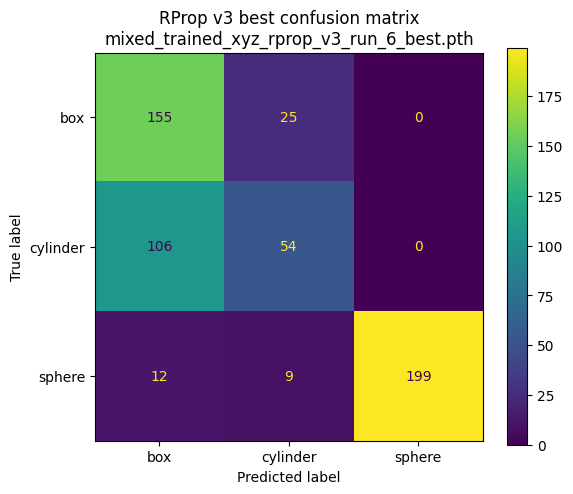

Saved:
/content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_best_confusion_matrix.csv
/content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/tables/rprop_v3_mean_confusion_matrix.csv
/content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/figures/rprop_v3_best_confusion_matrix.png


In [ ]:
# Cell 19 - RProp v3 Best and Mean Confusion Matrices

labels = ["box", "cylinder", "sphere"]

best_row = v3_ycb_summary_df.sort_values("accuracy_percent", ascending=False).iloc[0]
best_ckpt = best_row["checkpoint"]

print("Best RProp v3 checkpoint:", best_ckpt)
print("Best RProp v3 accuracy:", best_row["accuracy_percent"])

best_pred_df = v3_ycb_pred_df[v3_ycb_pred_df["checkpoint"] == best_ckpt].copy()

best_cm = confusion_matrix(
    best_pred_df["true_primitive"],
    best_pred_df["pred_primitive"],
    labels=labels
)

best_cm_df = pd.DataFrame(
    best_cm,
    index=[f"true_{x}" for x in labels],
    columns=[f"pred_{x}" for x in labels]
)

display(best_cm_df)

best_cm_path = V3_TABLE_DIR / "rprop_v3_best_confusion_matrix.csv"
best_cm_df.to_csv(best_cm_path)

cm_list = []

for ckpt in sorted(v3_ycb_pred_df["checkpoint"].unique()):
    part = v3_ycb_pred_df[v3_ycb_pred_df["checkpoint"] == ckpt]

    cm = confusion_matrix(
        part["true_primitive"],
        part["pred_primitive"],
        labels=labels
    )

    cm_list.append(cm)

mean_cm = np.mean(np.stack(cm_list), axis=0)

mean_cm_df = pd.DataFrame(
    mean_cm,
    index=[f"true_{x}" for x in labels],
    columns=[f"pred_{x}" for x in labels]
)

display(mean_cm_df)

mean_cm_path = V3_TABLE_DIR / "rprop_v3_mean_confusion_matrix.csv"
mean_cm_df.to_csv(mean_cm_path)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=labels)
disp.plot(ax=ax, values_format="d")
plt.title(f"RProp v3 best confusion matrix\n{best_ckpt}")
plt.tight_layout()
fig_path = V3_FIG_DIR / "rprop_v3_best_confusion_matrix.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:")
print(best_cm_path)
print(mean_cm_path)
print(fig_path)

In [ ]:
# Cell 20 - Load AdamW and RProp v3 Results Only for Final Comparison

def read_if_exists(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    raise FileNotFoundError(f"Missing file: {path}")

# AdamW final mixed result
adamw_path = PROJECT_DIR / "results_final_xyz" / "ycb28_results" / "pointnetpp_xyz_aps_to_ycb28_summary_runs.csv"

# RProp v3 final hybrid result
v3_summary_path = V3_YCB_DIR / "rprop_v3_mixed_xyz_ycb28_summary_runs_1_to_10.csv"
v3_pred_path = V3_YCB_DIR / "rprop_v3_mixed_xyz_ycb28_predictions_runs_1_to_10.csv"

print("AdamW path:", adamw_path)
print("RProp v3 summary path:", v3_summary_path)
print("RProp v3 prediction path:", v3_pred_path)

adamw_df = read_if_exists(adamw_path)
v3_summary = read_if_exists(v3_summary_path)

# Standardise AdamW accuracy column
if "accuracy_percent" in adamw_df.columns:
    adamw_df["standard_accuracy_percent"] = adamw_df["accuracy_percent"]
elif "test_accuracy_percent" in adamw_df.columns:
    adamw_df["standard_accuracy_percent"] = adamw_df["test_accuracy_percent"]
elif "accuracy" in adamw_df.columns:
    adamw_df["standard_accuracy_percent"] = adamw_df["accuracy"] * 100
else:
    raise RuntimeError("Could not identify AdamW accuracy column.")

# Keep only AdamW mixed condition
if "train_condition" in adamw_df.columns:
    adamw_mixed = adamw_df[adamw_df["train_condition"] == "mixed_trained_xyz"].copy()
elif "condition" in adamw_df.columns:
    adamw_mixed = adamw_df[adamw_df["condition"] == "mixed_trained_xyz"].copy()
else:
    adamw_mixed = adamw_df.copy()

if len(adamw_mixed) == 0:
    raise RuntimeError("No AdamW mixed_trained_xyz rows found.")

# Accuracy arrays
adamw_acc = adamw_mixed["standard_accuracy_percent"]
v3_acc = v3_summary["accuracy_percent"]

final_compare_df = pd.DataFrame([
    {
        "method": "AdamW mixed",
        "optimizer": "AdamW",
        "version": "final_main",
        "training_condition": "mixed_trained_xyz",
        "n_runs": len(adamw_acc),
        "min_accuracy": adamw_acc.min(),
        "q1_accuracy": adamw_acc.quantile(0.25),
        "median_accuracy": adamw_acc.median(),
        "q3_accuracy": adamw_acc.quantile(0.75),
        "max_accuracy": adamw_acc.max(),
        "mean_accuracy": adamw_acc.mean(),
        "std_accuracy": adamw_acc.std()
    },
    {
        "method": "RProp v3 final hybrid",
        "optimizer": "RProp",
        "version": "v3_final_hybrid",
        "training_condition": "mixed_trained_xyz_rprop_v3",
        "n_runs": len(v3_acc),
        "min_accuracy": v3_acc.min(),
        "q1_accuracy": v3_acc.quantile(0.25),
        "median_accuracy": v3_acc.median(),
        "q3_accuracy": v3_acc.quantile(0.75),
        "max_accuracy": v3_acc.max(),
        "mean_accuracy": v3_acc.mean(),
        "std_accuracy": v3_acc.std()
    }
])

display(final_compare_df)

final_compare_path = FINAL_COMPARE_DIR / "adamw_vs_rprop_v3_final_overall_comparison.csv"
final_compare_df.to_csv(final_compare_path, index=False)

print("Saved:", final_compare_path)

print("\nSummary:")
print("AdamW mixed mean accuracy:", adamw_acc.mean())
print("RProp v3 mean accuracy:", v3_acc.mean())
print("Difference AdamW - RProp v3:", adamw_acc.mean() - v3_acc.mean())

AdamW path: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/ycb28_results/pointnetpp_xyz_aps_to_ycb28_summary_runs.csv
RProp v3 summary path: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/results/ycb28_results/rprop_v3_mixed_xyz_ycb28_summary_runs_1_to_10.csv
RProp v3 prediction path: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/results/ycb28_results/rprop_v3_mixed_xyz_ycb28_predictions_runs_1_to_10.csv


,method,optimizer,version,training_condition,n_runs,min_accuracy,q1_accuracy,median_accuracy,q3_accuracy,max_accuracy,mean_accuracy,std_accuracy
0,AdamW mixed,AdamW,final_main,mixed_trained_xyz,9,85.714286,87.678571,90.000000,90.535714,91.250000,89.186508,1.902668
1,RProp v3 final hybrid,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,10,68.750000,70.625000,71.607143,72.098214,72.857143,71.196429,1.357482


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/final_comparison_tables/adamw_vs_rprop_v3_final_overall_comparison.csv

Summary:
AdamW mixed mean accuracy: 89.18650793650794
RProp v3 mean accuracy: 71.19642857142857
Difference AdamW - RProp v3: 17.990079365079367


In [ ]:
# Cell 21 - RProp v3 Class-Wise Results Only

def compute_classwise_from_predictions(pred_path, version_name):
    pred_df = pd.read_csv(pred_path)

    class_acc = (
        pred_df
        .groupby(["checkpoint", "true_primitive"])
        .agg(
            n_predictions=("correct", "count"),
            accuracy_percent=("correct", lambda x: x.mean() * 100),
            mean_confidence=("confidence", "mean")
        )
        .reset_index()
    )

    summary = (
        class_acc
        .groupby("true_primitive")
        .agg(
            n_checkpoints=("checkpoint", "count"),
            samples_per_checkpoint=("n_predictions", "mean"),
            mean_accuracy_percent=("accuracy_percent", "mean"),
            std_accuracy_percent=("accuracy_percent", "std"),
            median_accuracy_percent=("accuracy_percent", "median"),
            min_accuracy_percent=("accuracy_percent", "min"),
            max_accuracy_percent=("accuracy_percent", "max"),
            mean_confidence=("mean_confidence", "mean")
        )
        .reset_index()
    )

    summary["version"] = version_name

    return summary

v3_class_summary_final = compute_classwise_from_predictions(
    v3_pred_path,
    "RProp v3 final hybrid"
)

display(v3_class_summary_final)

v3_class_path = FINAL_COMPARE_DIR / "rprop_v3_final_classwise_summary.csv"
v3_class_summary_final.to_csv(v3_class_path, index=False)

print("Saved:", v3_class_path)

,true_primitive,n_checkpoints,samples_per_checkpoint,mean_accuracy_percent,std_accuracy_percent,median_accuracy_percent,min_accuracy_percent,max_accuracy_percent,mean_confidence,version
0,box,10,180.0,84.944444,5.088045,85.833333,76.111111,93.333333,0.690146,RProp v3 final hybrid
1,cylinder,10,160.0,29.812500,7.575144,29.062500,18.750000,40.625000,0.657221,RProp v3 final hybrid
2,sphere,10,220.0,90.045455,0.725060,90.454545,88.636364,90.909091,0.967063,RProp v3 final hybrid


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/final_comparison_tables/rprop_v3_final_classwise_summary.csv


In [ ]:
# Cell 22 - Final AdamW vs RProp v3 Decision

adamw_mean = final_compare_df[
    final_compare_df["method"] == "AdamW mixed"
]["mean_accuracy"].iloc[0]

rprop_v3_mean = final_compare_df[
    final_compare_df["method"] == "RProp v3 final hybrid"
]["mean_accuracy"].iloc[0]

difference = adamw_mean - rprop_v3_mean

print("AdamW mixed mean accuracy:", adamw_mean)
print("RProp v3 final hybrid mean accuracy:", rprop_v3_mean)
print("Difference AdamW - RProp v3:", difference)

if rprop_v3_mean > adamw_mean:
    final_decision = "RProp v3 outperformed AdamW on YCB-28. However, this should be checked carefully before changing the final model."
else:
    final_decision = "AdamW remains the final optimiser. RProp v3 is included only as a supplementary optimiser comparison."

decision_text = f"""
Final Optimiser Comparison Decision

Methods compared:
1. AdamW mixed-trained XYZ-only PointNet++
2. RProp v3 final hybrid mixed-trained XYZ-only PointNet++

AdamW mixed mean YCB-28 accuracy:
{adamw_mean:.4f}%

RProp v3 final hybrid mean YCB-28 accuracy:
{rprop_v3_mean:.4f}%

Difference:
AdamW minus RProp v3 = {difference:.4f} percentage points

Decision:
{final_decision}

Interpretation:
RProp v3 was tested as the final alternative optimiser configuration using the mixed APS training condition. The comparison is supplementary because the main model selection had already identified the AdamW mixed-trained XYZ-only PointNet++ as the strongest model.
"""

print(decision_text)

decision_path = FINAL_COMPARE_DIR / "adamw_vs_rprop_v3_final_decision_summary.txt"

with open(decision_path, "w") as f:
    f.write(decision_text)

print("Saved:", decision_path)

AdamW mixed mean accuracy: 89.18650793650794
RProp v3 final hybrid mean accuracy: 71.19642857142857
Difference AdamW - RProp v3: 17.990079365079367

Final Optimiser Comparison Decision

Methods compared:
1. AdamW mixed-trained XYZ-only PointNet++
2. RProp v3 final hybrid mixed-trained XYZ-only PointNet++

AdamW mixed mean YCB-28 accuracy:
89.1865%

RProp v3 final hybrid mean YCB-28 accuracy:
71.1964%

Difference:
AdamW minus RProp v3 = 17.9901 percentage points

Decision:
AdamW remains the final optimiser. RProp v3 is included only as a supplementary optimiser comparison.

Interpretation:
RProp v3 was tested as the final alternative optimiser configuration using the mixed APS training condition. The comparison is supplementary because the main model selection had already identified the AdamW mixed-trained XYZ-only PointNet++ as the strongest model.

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/final_comparison_tables/adamw_vs_rprop_v3_final_decision